# K-Means Clustering

### Import Data & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
abalone = fetch_ucirepo(id=1)

# data 
X = abalone.data.features
y = abalone.data.targets

# metadata
print(abalone.metadata)

# variable information
print(abalone.variables)

{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [3]:
y = y.squeeze()


In [4]:
X.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [5]:
X['Sex'] = pd.factorize(X['Sex'])[0]


In [6]:
mask = X["Sex"] != 2
X = X[mask]
y = y[mask]

### Train/Test Split

In [7]:
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=test_size,
                                                        random_state=random_state)
    return X_train, X_test, y_train, y_test


In [8]:
X_train, X_test, y_train, y_test = split_data(X, y)


### Hyperparameter Tuning

In [9]:
def tune_kmeans_model(X_train, k_range=range(2, 11)):
    """
    Tune the number of clusters (k) using the Elbow Method (inertia)
    and Silhouette Score. Returns the best k and its fitted model.
    """
    inertia_list = []
    silhouette_list = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_train)
        inertia_list.append(model.inertia_)
        silhouette_list.append(silhouette_score(X_train, labels))

    # Best k = highest silhouette score
    best_k = list(k_range)[np.argmax(silhouette_list)]
    best_params = {'n_clusters': best_k}

    # Fit final model with best k
    best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    best_model.fit(X_train)

    return best_model, best_params, inertia_list, silhouette_list

In [ ]:
# Standardize the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model, best_params, inertia_list, silhouette_list = tune_kmeans_model(X_train_scaled)

In [11]:
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'n_clusters': 2}


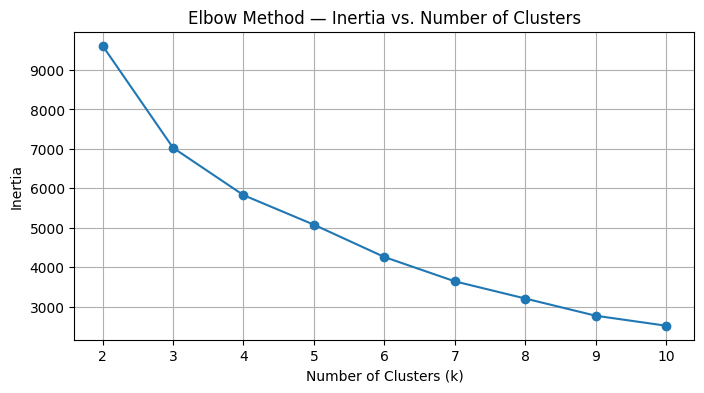

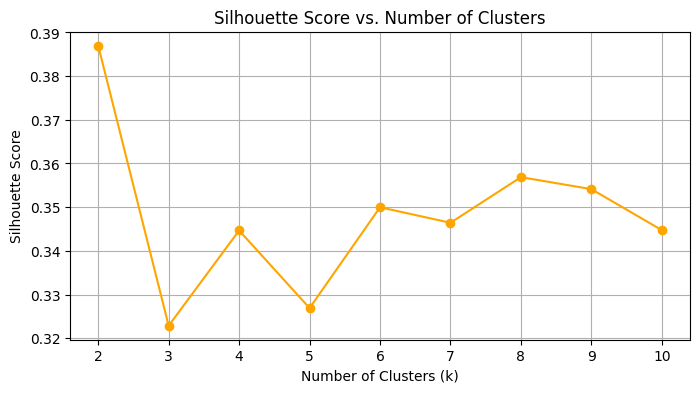

In [12]:
# Elbow plot
k_range = range(2, 11)
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia_list, marker='o')
plt.title('Elbow Method — Inertia vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Silhouette plot
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_list, marker='o', color='orange')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### Model

In [ ]:
def KMeans_model(X, y, num_replicates=30, test_size=0.2, k_range=range(2, 11)):
    """
    Function to replicate the K-Means model,
    perform hyperparameter tuning (k selection), and record results.

    Parameters:
    X: Features dataset
    y: Target variable (used only for train/test split consistency)
    num_replicates: Number of replicates to run the experiment
    test_size: Proportion of the dataset to include in the test split
    k_range: Range of cluster counts to evaluate

    Returns:
    silhouette_list: List of silhouette scores from each replicate
    inertia_list: List of inertia values from each replicate
    best_labels: Cluster labels from the best model (highest silhouette score)
    best_X_test: Scaled test set from the best replicate
    best_model_params: Hyperparameters of the best model
    """
    silhouette_list = []
    inertia_list = []
    best_silhouette = -1
    best_labels = None
    best_X_test = None
    best_model_params = None

    for i in range(num_replicates):
        # Train-test split
        X_train, X_test, y_train, y_test = split_data(X, y,
                                                       test_size=test_size,
                                                       random_state=i)

        # Standardize the data 
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Hyperparameter tuning 
        best_model, best_params, _, _ = tune_kmeans_model(X_train_scaled, k_range)

        # Predict cluster labels on the test set
        labels = best_model.predict(X_test_scaled)

        # Calculate silhouette score and inertia
        sil = silhouette_score(X_test_scaled, labels)
        inertia = best_model.inertia_

        # Record metrics
        silhouette_list.append(sil)
        inertia_list.append(inertia)

        # Update the best model based on the highest silhouette score
        if sil > best_silhouette:
            best_silhouette = sil
            best_labels = labels
            best_X_test = X_test_scaled
            best_model_params = best_params

    return silhouette_list, inertia_list, best_labels, best_X_test, best_model_params


In [14]:
silhouette_list, inertia_list, best_labels, best_X_test, best_model_params = KMeans_model(X, y)


### Model Evaluation

In [15]:
num_replicates = 30


In [16]:
print(f'Silhouette Scores from {num_replicates} replicates: {silhouette_list}')
print(f'Inertia from {num_replicates} replicates: {inertia_list}')

Silhouette Scores from 30 replicates: [0.3807688435363792, 0.3640208574350055, 0.37724933758619444, 0.3711214889718346, 0.3824231044630058, 0.38755069296978173, 0.3872594345410634, 0.3806541261072616, 0.3816073433796924, 0.38534374195275073, 0.3825043220563075, 0.35557613677151007, 0.39826131866799647, 0.39862374900166997, 0.39291255196155067, 0.38258187065945454, 0.38493959332510524, 0.393095351155021, 0.38812039680060934, 0.4171598477525124, 0.3837612716343188, 0.37850685596339856, 0.36930803184398836, 0.3848074708886859, 0.3764153540125136, 0.3784292761296695, 0.39103129511387175, 0.39141567695619256, 0.396566319469181, 0.39140034034335924]
Inertia from 30 replicates: [9311.201640228657, 9499.012830730684, 9572.041210558416, 9578.193785119729, 9606.594919953259, 9623.731702565281, 9641.922693595596, 9606.405354182034, 9594.279639697763, 9642.326740193392, 9597.17957995597, 9255.157634510591, 9447.808145867572, 9651.536838339962, 9667.619610202315, 9633.355470420862, 9633.4966354886,

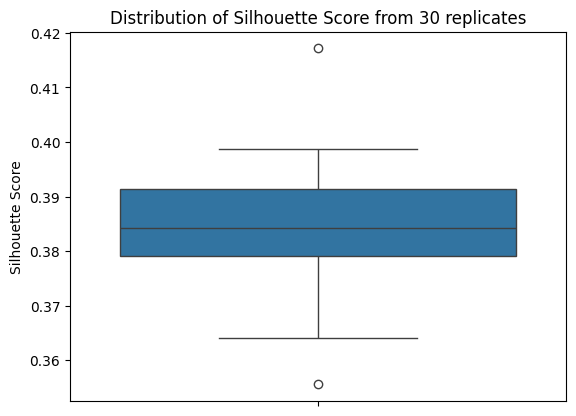

In [17]:
# Create the boxplot
sns.boxplot(data=silhouette_list)

# Adding labels and title
plt.title('Distribution of Silhouette Score from 30 replicates')
plt.ylabel('Silhouette Score')

# Show the plot
plt.show()

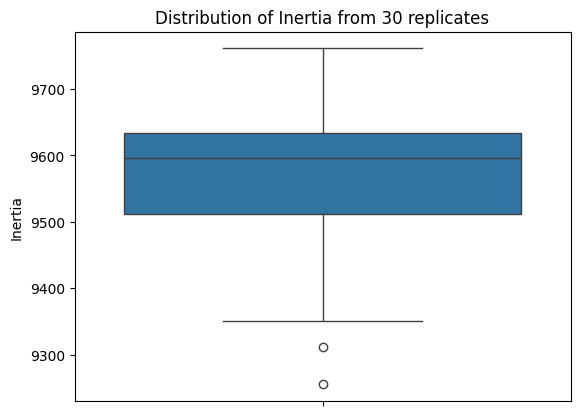

In [18]:
# Create the boxplot
sns.boxplot(data=inertia_list)

# Adding labels and title
plt.title('Distribution of Inertia from 30 replicates')
plt.ylabel('Inertia')

# Show the plot
plt.show()

In [19]:
def plot_clusters(X_scaled, labels):
    """
    Visualize clusters using PCA to reduce to 2D.
    Analogous to plot_true_vs_pred — shows the best replicate's cluster assignments.
    """
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                          c=labels, cmap='tab10',
                          alpha=0.6, edgecolors='k')
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('K-Means Cluster Assignments (Best Replicate, PCA-reduced)')
    plt.grid(True)
    plt.show()


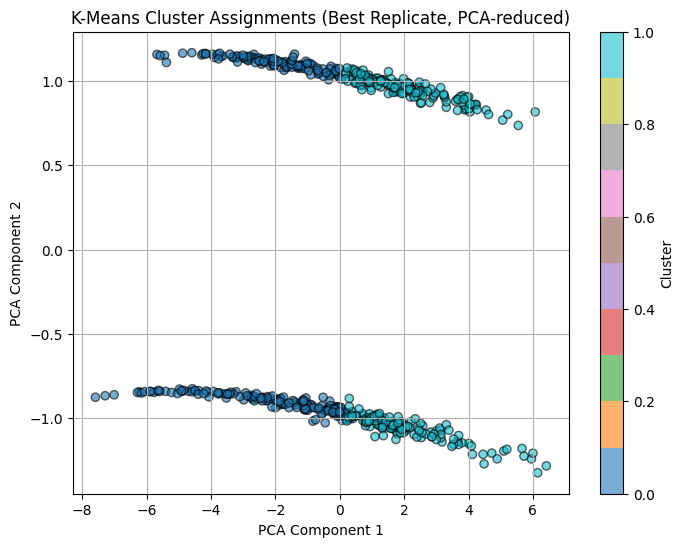

In [20]:
plot_clusters(best_X_test, best_labels)
